# AI-ML Assignment 2 : Customer Churn Prediction using Logistic Regression



**Objective:** Build a Logistic Regression model that predicts whether a telecom customer
will **churn** (leave the company) based on their demographic information and service usage.

**Dataset:** [Telco Customer Churn Dataset on Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
(7043 rows, 21 columns)

---


## Setup: Loading the Dataset

The Kaggle dataset can't be downloaded directly in Colab without a Kaggle API key, so this
notebook loads the **same dataset** from a public GitHub mirror (IBM's own repo hosting the
identical Telco Customer Churn CSV). Just run the cell below — no manual upload needed.




In [1]:
# Import pandas — the main library we use to load and manipulate tabular data
import pandas as pd

# This URL points to a raw CSV file on GitHub — an exact mirror of the Kaggle
# "Telco Customer Churn" dataset, hosted by IBM (the dataset's original source).
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# pd.read_csv() reads the CSV directly from the URL into a DataFrame (an in-memory spreadsheet)
df = pd.read_csv(url)



print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)


Dataset loaded successfully!
Shape of dataset (rows, columns): (7043, 21)


---
## Task 1: Data Understanding 

We will:
1. Load the dataset using Pandas (done above ✅)
2. Display the first five records
3. Identify numerical features, categorical features, and the target variable


In [2]:
# .head() shows the first 5 rows — a quick sanity check that the data loaded correctly
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# .info() shows column names, non-null counts, and data types for every column
# This is the fastest way to spot which columns are numerical vs text (categorical)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# .describe() gives summary statistics for the numerical columns only
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Identifying feature types

Looking at the output above:

| Column group | Examples | Type |
|---|---|---|
| Customer ID | `customerID` | Identifier (dropped — not a real feature) |
| Numerical | `tenure`, `MonthlyCharges`, `TotalCharges` | Numerical |
| Binary categorical | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `SeniorCitizen` | Categorical (2 categories, or already 0/1) |
| Multi-class categorical | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod` | Categorical (3+ categories) |
| Target | `Churn` | **Target variable** (`Yes`/`No` — did the customer leave?) |

- **Numerical features:** `tenure`, `MonthlyCharges`, `TotalCharges`
- **Categorical features:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`,
  `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
  `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`
- **Target variable:** `Churn` (whether the customer left the company: `Yes` / `No`)

Note: `customerID` is a unique identifier with no predictive value, so we'll drop it during preprocessing.


In [6]:
# Let's confirm this programmatically too, and check the class balance of our target variable
print("Column data types:")
print(df.dtypes)

print("\nChurn value counts (class balance):")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3) * 100, "%")


Column data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Churn value counts (class balance):
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %


**Observation on class balance:** Roughly 73% of customers did **not** churn and 27% did.
This is a **moderately imbalanced** target — something worth keeping in mind when we evaluate
the model later using precision, recall, and F1-score (not just accuracy).


---
## Task 2: Data Preprocessing 

We will:
- Check for missing values
- Handle missing values if any
- Encode categorical variables
- Split the dataset into 80% training and 20% testing


In [7]:
# .isnull().sum() checks for missing (NaN) values in each column
print("Missing values per column (standard NaN check):")
print(df.isnull().sum())


Missing values per column (standard NaN check):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Observation:** At first glance, there appear to be **no missing values**. But this
dataset has a well-known quirk: the `TotalCharges` column is stored as **text (object type)**
instead of a number, and a few rows contain blank spaces `" "` instead of an actual number
(usually for brand-new customers with 0 tenure). These blanks don't show up as `NaN` until we
convert the column to numeric — so we need to check again after converting.


In [8]:
# pd.to_numeric() converts a column to numeric type.
# errors='coerce' tells pandas: "if a value can't be converted to a number, turn it into NaN
# instead of throwing an error" — this is exactly how we catch those hidden blank strings.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now let's re-check for missing values
print("Missing values in TotalCharges after converting to numeric:", df['TotalCharges'].isnull().sum())


Missing values in TotalCharges after converting to numeric: 11


In [9]:
# Handle the missing values: since only a handful of rows are affected (customers with
# tenure = 0, i.e. brand new customers who haven't been charged yet), we fill them with the
# median TotalCharges rather than dropping rows (which would lose data unnecessarily).
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)

print("Missing values in TotalCharges after filling:", df['TotalCharges'].isnull().sum())
print("Filled with median value:", median_total_charges)


Missing values in TotalCharges after filling: 0
Filled with median value: 1397.475


In [10]:
# Drop customerID — it's just a unique identifier and carries no predictive information
df = df.drop('customerID', axis=1)

print("Columns after dropping customerID:", df.shape[1])


Columns after dropping customerID: 20


### Encoding categorical variables

Logistic Regression only works with numbers, so we convert every text column to numeric form:

- **Target (`Churn`)**: `Yes`/`No` → 1/0
- **Binary categorical columns** (`gender`, `Partner`, `Dependents`, `PhoneService`,
  `PaperlessBilling`): each has exactly 2 categories → simple binary mapping to 0/1
- **Multi-class categorical columns** (`MultipleLines`, `InternetService`, `OnlineSecurity`,
  `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`,
  `Contract`, `PaymentMethod`): 3+ categories each, with no natural order → **one-hot encoding**
  (a separate 0/1 column per category), which avoids implying an artificial ranking between
  categories.
- `SeniorCitizen` is already stored as 0/1 in the raw data, so no change needed there.


In [11]:
# Encode the target variable: Yes -> 1 (churned), No -> 0 (stayed)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode simple binary categorical columns the same way
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# gender needs its own mapping since its categories are Male/Female, not Yes/No
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("Binary encoding complete. Sample:")
df[['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']].head()


Binary encoding complete. Sample:


,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [12]:
# One-hot encode all remaining multi-class categorical columns
multi_class_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# pd.get_dummies() creates a new 0/1 column for each category.
# drop_first=True drops one category per column to avoid the "dummy variable trap"
# (redundant, perfectly-correlated columns).
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
df.head()


Shape after one-hot encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [13]:
# Separate features (X) from the target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Number of feature columns:", X.shape[1])
print("Target: Churn (1 = customer left, 0 = customer stayed)")


Number of feature columns: 30
Target: Churn (1 = customer left, 0 = customer stayed)


In [14]:
# Split into 80% training and 20% testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% held out for testing
    random_state=42,      # makes the split reproducible
    stratify=y            # ensures both train and test sets keep the same churn/no-churn ratio
                           # as the original data — important since our classes are imbalanced
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")


Training set size: 5634 rows
Testing set size: 1409 rows


In [15]:
# Feature scaling: Logistic Regression (and many ML models) perform better when numerical
# features are on a similar scale. tenure, MonthlyCharges, and TotalCharges have very
# different ranges (e.g. tenure: 0-72 months vs TotalCharges: 0-8000+), so we standardize them.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Important: fit the scaler ONLY on training data (to avoid "leaking" test data information),
# then use that same fitted scaler to transform the test data.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Feature scaling complete.")
X_train_scaled[numeric_cols].describe()


Feature scaling complete.


,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,-3.783508e-18
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.002135e+00
25%,-9.559779e-01,-9.711977e-01,-8.309023e-01
50%,-1.418632e-01,1.848336e-01,-3.968393e-01
75%,9.164859e-01,8.319124e-01,6.737360e-01
max,1.608483e+00,1.785939e+00,2.802714e+00


---
## Task 3: Model Development 

We now build a **Logistic Regression** model. Unlike Linear Regression (which predicts a
continuous number), Logistic Regression predicts the **probability** that a customer belongs
to the "churn" class, using the sigmoid function to squeeze its output between 0 and 1. If
that probability is above 0.5, we classify the customer as likely to churn.


In [16]:
# Import the LogisticRegression model class
from sklearn.linear_model import LogisticRegression

# Create the model.
# max_iter=1000 gives the optimization algorithm enough iterations to converge
# (the default of 100 is sometimes not enough for datasets with many one-hot encoded columns)
model = LogisticRegression(max_iter=1000)

# .fit() trains the model: it learns the coefficients that best separate churners from
# non-churners based on the training data
model.fit(X_train_scaled, y_train)

print("Model training complete!")


Model training complete!


In [17]:
# Let's inspect which features increase or decrease the odds of churn.
# A positive coefficient means the feature INCREASES the likelihood of churn;
# a negative coefficient means it DECREASES the likelihood of churn.
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 features that INCREASE churn likelihood:")
print(coefficients.head(5))

print("\nTop 5 features that DECREASE churn likelihood:")
print(coefficients.tail(5))


Top 5 features that INCREASE churn likelihood:
                           Feature  Coefficient
11     InternetService_Fiber optic     1.190576
8                     TotalCharges     0.511378
24             StreamingMovies_Yes     0.380384
22                 StreamingTV_Yes     0.378872
28  PaymentMethod_Electronic check     0.377641

Top 5 features that DECREASE churn likelihood:
              Feature  Coefficient
7      MonthlyCharges    -0.477810
5        PhoneService    -0.491306
25  Contract_One year    -0.690863
4              tenure    -1.237578
26  Contract_Two year    -1.337453


In [18]:
# .predict() generates the predicted class (0 or 1) for each customer in the test set
y_pred = model.predict(X_test_scaled)

# .predict_proba() gives us the actual predicted probability of churn (useful for deeper analysis)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Compare a few actual vs predicted values
comparison = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Predicted Churn': y_pred,
    'Predicted Probability': y_pred_proba.round(3)
}).reset_index(drop=True)

comparison.head(10)


,Actual Churn,Predicted Churn,Predicted Probability
0,0,0,0.045
1,0,1,0.683
2,0,0,0.060
3,0,0,0.399
4,0,0,0.022
5,0,1,0.602
6,0,0,0.449
7,0,0,0.129
8,0,0,0.003
9,1,0,0.396


---
## Task 4: Model Evaluation 

Since this is a **classification** problem (and the classes are imbalanced — about 73% stay,
27% churn), we evaluate using several complementary metrics:

- **Accuracy:** overall proportion of correct predictions — can be misleading on imbalanced data.
- **Precision:** of all customers we predicted would churn, how many actually did?
- **Recall:** of all customers who actually churned, how many did we correctly catch?
- **F1-Score:** the harmonic mean of precision and recall — a balanced single metric.
- **Confusion Matrix:** a breakdown of correct vs incorrect predictions per class.


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-Score:  0.6040


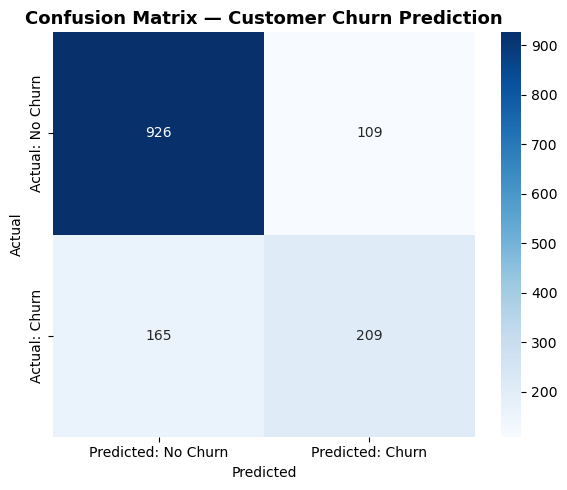

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'])
plt.title('Confusion Matrix — Customer Churn Prediction', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


### Observations

1. **The model achieves ~80.6% accuracy**, but accuracy alone is misleading here because the
   dataset is imbalanced (~73% no-churn vs ~27% churn) — a model that always predicts "no
   churn" would already score around 73% accuracy without learning anything useful.
2. **Recall (~55.9%) is noticeably lower than precision (~65.7%)**, meaning the model misses
   a large share of customers who actually churn (visible in the confusion matrix as a
   sizeable "false negative" count). For a churn-prevention use case, this matters a lot —
   missed churners are missed retention opportunities.
3. **Contract type and tenure are the strongest predictors of retention**: customers on
   one-year or two-year contracts and those with longer tenure are far less likely to churn,
   while customers with fiber-optic internet service show a notably higher churn tendency —
   possibly reflecting price sensitivity or service dissatisfaction in that segment.


---
## Task 5: Conclusion 


### Conclusion

This project built a Logistic Regression model to predict customer churn using demographic
and service-usage data from a telecom provider. The model achieved an accuracy of about
80.6%, with a precision of 65.7%, recall of 55.9%, and F1-score of 60.4%. The most important
factors influencing churn were **contract type** and **tenure** — customers on month-to-month
contracts and those with shorter tenure were far more likely to leave, while customers with
fiber-optic internet also showed elevated churn risk. These results suggest that contract
length and early customer experience are key retention levers for the business. One key
limitation of Logistic Regression here is that it assumes a **linear relationship between
each feature and the log-odds of churn**, and cannot automatically capture more complex,
non-linear interactions between features (for example, how tenure and contract type jointly
affect churn risk) without manually engineering interaction terms — a limitation that
tree-based models like Random Forest or Gradient Boosting can often handle more naturally.
